# **Music Collection Analysis**
**By Francisco Lazarte**

**June 7th, 2024**

## Introduction

Welcome to the analysis of my music collection! We'll dive into the data, clean it up, and uncover some fascinating insights with visualizations.


## 1. Importing Libraries and Loading Data
First things first, let's import the necessary libraries and load our dataset.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
music_collection = pd.read_csv("/content/fran_collection_05-06-2024.csv")

## 2. Understanding the Data
Let's take a quick peek at the data to understand its structure and identify any missing values.

In [ ]:
music_collection.head()

,Catalog#,Artist,Title,Label,Format,Rating,Released,release_id,CollectionFolder,Date Added,Collection Media Condition,Collection Sleeve Condition,Collection Notes
0,116P,George Clanton,Slide,100% Electronica,"10xFile, MP3, Album, 320",NaN,2018,12417679,Uncategorized,2024-01-18 14:59:07,NaN,NaN,NaN
1,6370 243,The Alan Parsons Project,Tales Of Mystery And Imagination,20th Century Records,"LP, Album, Gat",NaN,1976,460238,Uncategorized,2024-05-27 16:59:32,NaN,NaN,NaN
2,Cad 0012 cd,Cocteau Twins,Heaven Or Las Vegas,4AD,"CD, Album",NaN,1990,28514,Uncategorized,2024-01-18 15:06:33,NaN,NaN,NaN
3,CAD 611 CD,"Harold Budd, Simon Raymonde, Robin Guthrie, El...",The Moon And The Melodies,4AD,"CD, Album, MPO",NaN,1986,28523,Uncategorized,2024-01-20 04:40:56,NaN,NaN,NaN
4,EAD3535A,Grimes (4),Art Angels,4AD,"14xFile, MP3, Album, 320",NaN,2015,7691990,Uncategorized,2024-01-18 14:58:21,NaN,NaN,NaN


In [ ]:
music_collection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Catalog#                     258 non-null    object 
 1   Artist                       258 non-null    object 
 2   Title                        258 non-null    object 
 3   Label                        258 non-null    object 
 4   Format                       258 non-null    object 
 5   Rating                       0 non-null      float64
 6   Released                     258 non-null    int64  
 7   release_id                   258 non-null    int64  
 8   CollectionFolder             258 non-null    object 
 9   Date Added                   258 non-null    object 
 10  Collection Media Condition   0 non-null      float64
 11  Collection Sleeve Condition  0 non-null      float64
 12  Collection Notes             0 non-null      float64
dtypes: float64(4), int64

In [ ]:
music_collection.isnull().sum()

Catalog#                         0
Artist                           0
Title                            0
Label                            0
Format                           0
Rating                         258
Released                         0
release_id                       0
CollectionFolder                 0
Date Added                       0
Collection Media Condition     258
Collection Sleeve Condition    258
Collection Notes               258
dtype: int64

I noticed the columns I'm interested in: "Artist", "Title", "Released", and "Label". So let's select them:

In [ ]:
df_selected = music_collection[['Artist', 'Title', 'Released', 'Label']]

In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Artist    258 non-null    object
 1   Title     258 non-null    object
 2   Released  258 non-null    int64 
 3   Label     258 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.2+ KB


## 3. Cleaning Data
I found out that the "Released" column is in the wrong format (int64). Since it represents the year of release, we'll convert it to a date format.

I saw previously that "Released" was in the wrong format: int64
So I want to change it to date format since it represents the year of release of each record.

In [ ]:
df_selected.loc[:, 'Released'] = pd.to_datetime(df_selected['Released'].astype(str), format='%Y', errors='coerce')

In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Artist    258 non-null    object        
 1   Title     258 non-null    object        
 2   Released  253 non-null    datetime64[ns]
 3   Label     258 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 8.2+ KB


In [ ]:
df_selected.head()

,Artist,Title,Released,Label
0,George Clanton,Slide,2018-01-01,100% Electronica
1,The Alan Parsons Project,Tales Of Mystery And Imagination,1976-01-01,20th Century Records
2,Cocteau Twins,Heaven Or Las Vegas,1990-01-01,4AD
3,"Harold Budd, Simon Raymonde, Robin Guthrie, El...",The Moon And The Melodies,1986-01-01,4AD
4,Grimes (4),Art Angels,2015-01-01,4AD


## 4. Data Analysis and Visualization
Here comes the fun part! I'll use a dark background with a blue palette for my visualizations. 🌌🔵

In [ ]:
# Set the style
sns.set(style="darkgrid")
plt.style.use("dark_background")

#### Top 10 Artists by Number of Records

Let's see who dominates my collection.

<ipython-input-21-8b67afc94cd4>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=artist_count.values, y=artist_count.index, palette="Blues_r")


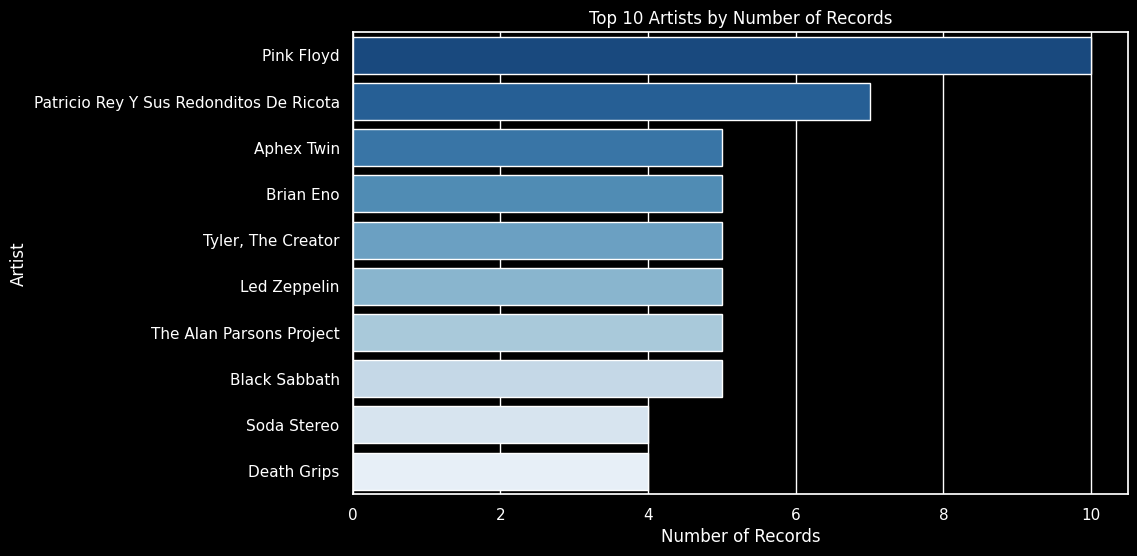

In [ ]:
# Count of records by artist
plt.figure(figsize=(10, 6))
artist_count = df_selected['Artist'].value_counts().head(10)
sns.barplot(x=artist_count.values, y=artist_count.index, palette="Blues_r")
plt.title('Top 10 Artists by Number of Records')
plt.xlabel('Number of Records')
plt.ylabel('Artist')
plt.show()

#### Distribution of Records by Release Year

How does my music taste adapt over the years? Let's find out!

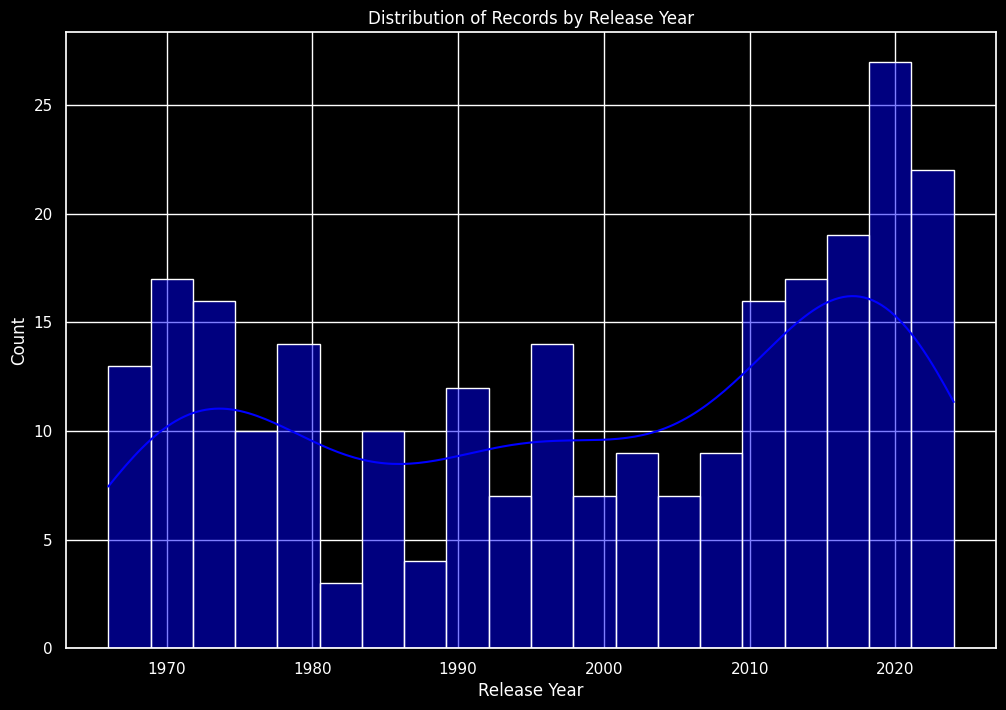

In [ ]:
# Distribution of records by release year
plt.figure(figsize=(12, 8))
sns.histplot(df_selected['Released'].dt.year, bins=20, kde=True, color='blue')
plt.title('Distribution of Records by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

#### Top 10 Labels by Number of Records

Which record labels are most represented in my collection?

<ipython-input-64-15c926d47a54>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_count.values, y=label_count.index, palette="Blues_r")


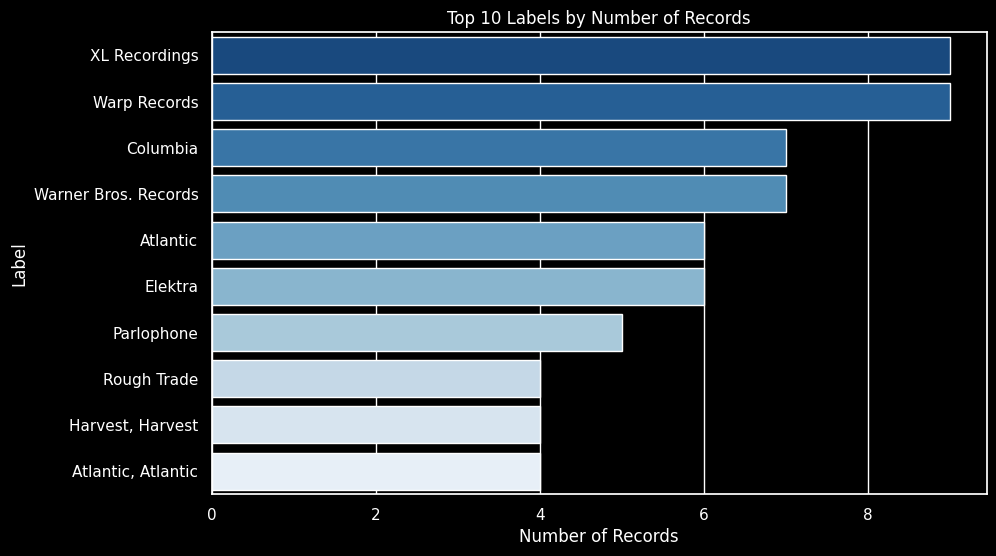

In [ ]:
# Count of records by label
plt.figure(figsize=(10, 6))
label_count = df_selected['Label'].value_counts().head(10)
sns.barplot(x=label_count.values, y=label_count.index, palette="Blues_r")
plt.title('Top 10 Labels by Number of Records')
plt.xlabel('Number of Records')
plt.ylabel('Label')
plt.show()

#### Distribution of Records per Century

Let's break it down by century for a broader view.

Century
21st Century    129
20th Century    124
Name: count, dtype: int64


<ipython-input-65-a93751356b2b>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['Century'] = df_selected['Released'].dt.year.apply(get_century)


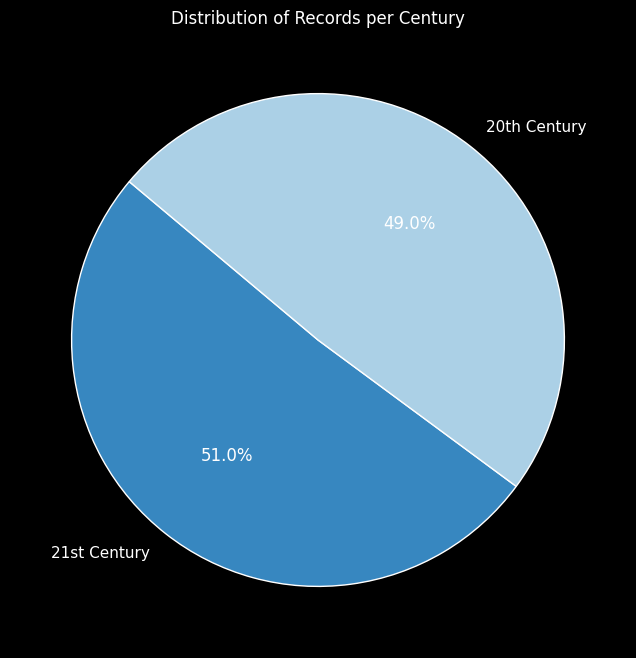

In [ ]:
# Define a function to categorize the release year into centuries
def get_century(year):
    if pd.isnull(year):
        return np.nan
    elif year < 1900:
        return 'Before 20th Century'
    elif year < 2000:
        return '20th Century'
    else:
        return '21st Century'

# Apply the function to create a new column 'Century'
df_selected['Century'] = df_selected['Released'].dt.year.apply(get_century)

# Verify the changes
print(df_selected['Century'].value_counts())

# Count the number of records per century
century_count = df_selected['Century'].value_counts()

# Plot the pie chart
plt.figure(figsize=(10, 8))
century_count.plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Blues_r", len(century_count)))
plt.title('Distribution of Records per Century')
plt.ylabel('')  # Hide the y-label
plt.show()

## 5. Conclusion
After analyzing my music collection, here are the key insights:

**Top Artists**

Pink Floyd dominates my collection with 10 records.

Patricio Rey Y Sus Redonditos De Ricota follows with 7 records.

Aphex Twin and Brian Eno each have 5 records.

Other notable mentions include Tyler, The Creator, Led Zeppelin, The Alan Parsons Project, Black Sabbath, Soda Stereo, and Death Grips, each with multiple records.

This shows a strong preference for progressive rock and electronic music, reflecting my diverse taste in complex and experimental sounds.



**Release Years**

The distribution of records by release year reveals two significant peaks:

The 1970s saw a surge, with notable peaks in the early and mid-70s.

The 2010s and 2020s also saw a resurgence, particularly around 2020.

These peaks indicate a blend of classic rock from the 70s and contemporary music from the last decade.

**Top Labels**

XL Recordings and Warp Records lead with 8 records each.

Columbia, Warner Bros. Records, and Atlantic are also prominent with multiple records.

These labels are known for their diverse rosters and innovative artists, suggesting that I appreciate both mainstream and avant-garde music.

**Records per Century**

The collection is almost evenly split between the 20th Century (49%) and the 21st Century (51%).

This even distribution highlights my appreciation for both classic and modern music, blending the timeless appeal of older records with the fresh perspectives of contemporary artists.

**Additional Insights**

Average Number of Records per Artist: The diversity in my collection is evident, with an average of around 4-5 records per top artist, indicating that while I have favorites, I also explore a wide range of artists.

Distribution by Label: The top labels in my collection suggest a preference for high-quality production and innovative sounds, as these labels are known for pushing musical boundaries.

These insights paint a vivid picture of my music preferences, showing a balanced appreciation for both historical and modern music, across a variety of genres and labels. My collection reflects a journey through the rich landscape of music, from the classics of the 70s to the experimental and diverse sounds of today.

Thanks for joining me on this musical exploration!